In [13]:
import pandas as pd
import re

In [14]:


# # Function to parse the HURDAT2 file
# def parse_hurdat2(file_content):
#     # Split the content into lines
#     lines = file_content.strip().split('\n')
    
#     data = []
#     current_header = None
    
#     for line in lines:
#         if line.startswith('AL'):  # This is a header line
#             # Parse header information
#             parts = line.split(',')
#             basin_id = parts[0].strip()
#             name = parts[1].strip()
#             num_entries = int(parts[2].strip())
            
#             current_header = {
#                 'basin_id': basin_id,
#                 'name': name,
#                 'num_entries': num_entries
#             }
#         else:  # This is a data line
#             if current_header:
#                 # Parse data line
#                 parts = line.split(',')
                
#                 # Extract date and time
#                 date_str = parts[0].strip()
#                 time_str = parts[1].strip()
                
#                 year = int(date_str[0:4])
#                 month = int(date_str[4:6])
#                 day = int(date_str[6:8])
                
#                 if time_str:
#                     hour = int(time_str[0:2])
#                     minute = int(time_str[2:4]) if len(time_str) >= 4 else 0
#                 else:
#                     hour = minute = 0
                
#                 # Record identifier
#                 record_id = parts[2].strip()
                
#                 # Status
#                 status = parts[3].strip()
                
#                 # Location
#                 lat_str = parts[4].strip()
#                 lon_str = parts[5].strip()
                
#                 lat = float(lat_str[:-1]) * (1 if lat_str[-1] == 'N' else -1)
#                 lon = float(lon_str[:-1]) * (-1 if lon_str[-1] == 'W' else 1)
                
#                 # Wind speed
#                 max_wind = int(parts[6].strip()) if parts[6].strip() != '-999' else None
                
#                 # Pressure
#                 min_pressure = int(parts[7].strip()) if parts[7].strip() != '-999' else None
                
#                 # Wind radii data (if available)
#                 ne_34kt = int(parts[8].strip()) if parts[8].strip() != '-999' else None
#                 se_34kt = int(parts[9].strip()) if parts[9].strip() != '-999' else None
#                 sw_34kt = int(parts[10].strip()) if parts[10].strip() != '-999' else None
#                 nw_34kt = int(parts[11].strip()) if parts[11].strip() != '-999' else None
                
#                 ne_50kt = int(parts[12].strip()) if parts[12].strip() != '-999' else None
#                 se_50kt = int(parts[13].strip()) if parts[13].strip() != '-999' else None
#                 sw_50kt = int(parts[14].strip()) if parts[14].strip() != '-999' else None
#                 nw_50kt = int(parts[15].strip()) if parts[15].strip() != '-999' else None
                
#                 ne_64kt = int(parts[16].strip()) if parts[16].strip() != '-999' else None
#                 se_64kt = int(parts[17].strip()) if parts[17].strip() != '-999' else None
#                 sw_64kt = int(parts[18].strip()) if parts[18].strip() != '-999' else None
#                 nw_64kt = int(parts[19].strip()) if parts[19].strip() != '-999' else None
                
#                 # Radius of Maximum Wind
#                 rmw = int(parts[20].strip()) if len(parts) > 20 and parts[20].strip() != '-999' else None
                
#                 # Add to data list
#                 data.append({
#                     'basin_id': current_header['basin_id'],
#                     'storm_name': current_header['name'],
#                     'year': year,
#                     'month': month,
#                     'day': day,
#                     'hour': hour,
#                     'minute': minute,
#                     'record_id': record_id,
#                     'status': status,
#                     'latitude': lat,
#                     'longitude': lon,
#                     'max_wind': max_wind,
#                     'min_pressure': min_pressure,
#                     'ne_34kt_radius': ne_34kt,
#                     'se_34kt_radius': se_34kt,
#                     'sw_34kt_radius': sw_34kt,
#                     'nw_34kt_radius': nw_34kt,
#                     'ne_50kt_radius': ne_50kt,
#                     'se_50kt_radius': se_50kt,
#                     'sw_50kt_radius': sw_50kt,
#                     'nw_50kt_radius': nw_50kt,
#                     'ne_64kt_radius': ne_64kt,
#                     'se_64kt_radius': se_64kt,
#                     'sw_64kt_radius': sw_64kt,
#                     'nw_64kt_radius': nw_64kt,
#                     'radius_max_wind': rmw
#                 })
    
#     # Create DataFrame
#     df = pd.DataFrame(data)
    
#     # Create datetime column
#     df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute']])
    
#     return df

# # Parse the HURDAT2 data
# with open('project_folder/Wind/Hurricane/NOAA HURDAT2/hurdat2-1851-2023-051124.txt', 'r') as f:
#     content = f.read()
    
# hurdat_df = parse_hurdat2(content)

# # Display the first few rows
# print(hurdat_df.head())

# # Summary information
# print(f"\nTotal records: {len(hurdat_df)}")
# print(f"Number of unique storms: {hurdat_df['basin_id'].nunique()}")
# print(f"Date range: {hurdat_df['datetime'].min()} to {hurdat_df['datetime'].max()}")

In [15]:
import pandas as pd
import re
from datetime import datetime

# Function to parse the HURDAT2 file with separated basin and cyclone number
def parse_hurdat2(file_content):
    # Split the content into lines
    lines = file_content.strip().split('\n')
    
    data = []
    current_header = None
    
    for line in lines:
        if re.match(r'^[A-Z]{2}\d{6}', line):  # This is a header line (starts with AL, EP, etc. followed by numbers)
            # Parse header information
            parts = line.split(',')
            basin_id = parts[0].strip()
            
            # Separate basin and cyclone number
            basin = basin_id[:2]  # First two characters (AL, EP, etc.)
            cyclone_number = basin_id[2:4]  # Characters 3-4 (cyclone number)
            year = basin_id[4:8]  # Last four digits (year)
            
            name = parts[1].strip()
            num_entries = int(parts[2].strip())
            
            current_header = {
                'basin': basin,
                'cyclone_number': cyclone_number,
                'year': year,
                'full_id': basin_id,
                'name': name,
                'num_entries': num_entries
            }
        else:  # This is a data line
            if current_header:
                # Parse data line
                parts = line.split(',')
                
                # Extract date and time
                date_str = parts[0].strip()
                time_str = parts[1].strip()
                
                year = int(date_str[0:4])
                month = int(date_str[4:6])
                day = int(date_str[6:8])
                
                if time_str:
                    hour = int(time_str[0:2])
                    minute = int(time_str[2:4]) if len(time_str) >= 4 else 0
                else:
                    hour = minute = 0
                
                # Record identifier
                record_id = parts[2].strip()
                
                # Status
                status = parts[3].strip()
                
                # Location - Improved parsing of latitude and longitude
                lat_str = parts[4].strip()
                lon_str = parts[5].strip()
                
                # Extract the numeric part and the hemisphere indicator for latitude
                if lat_str:
                    if lat_str[-1] in ['N', 'S']:  # Check if hemisphere indicator is present
                        lat_value = float(lat_str[:-1])
                        lat = lat_value if lat_str[-1] == 'N' else -lat_value
                    else:
                        lat = float(lat_str)  # No hemisphere indicator
                else:
                    lat = None
                        
                # Extract the numeric part and the hemisphere indicator for longitude
                if lon_str:
                    if lon_str[-1] in ['E', 'W']:  # Check if hemisphere indicator is present
                        lon_value = float(lon_str[:-1])
                        lon = lon_value if lon_str[-1] == 'E' else -lon_value
                    else:
                        lon = float(lon_str)  # No hemisphere indicator
                else:
                    lon = None
                
                # Wind speed
                max_wind = int(parts[6].strip()) if parts[6].strip() not in ['-999', ''] else None
                
                # Pressure
                min_pressure = int(parts[7].strip()) if parts[7].strip() not in ['-999', ''] else None
                
                # Wind radii data - initialize all as None
                ne_34kt = se_34kt = sw_34kt = nw_34kt = None
                ne_50kt = se_50kt = sw_50kt = nw_50kt = None
                ne_64kt = se_64kt = sw_64kt = nw_64kt = None
                rmw = None
                
                # Extract wind radii data safely with length checks
                if len(parts) > 8 and parts[8].strip() not in ['-999', '']:
                    ne_34kt = int(parts[8].strip())
                    
                if len(parts) > 9 and parts[9].strip() not in ['-999', '']:
                    se_34kt = int(parts[9].strip())
                    
                if len(parts) > 10 and parts[10].strip() not in ['-999', '']:
                    sw_34kt = int(parts[10].strip())
                    
                if len(parts) > 11 and parts[11].strip() not in ['-999', '']:
                    nw_34kt = int(parts[11].strip())
                
                if len(parts) > 12 and parts[12].strip() not in ['-999', '']:
                    ne_50kt = int(parts[12].strip())
                    
                if len(parts) > 13 and parts[13].strip() not in ['-999', '']:
                    se_50kt = int(parts[13].strip())
                    
                if len(parts) > 14 and parts[14].strip() not in ['-999', '']:
                    sw_50kt = int(parts[14].strip())
                    
                if len(parts) > 15 and parts[15].strip() not in ['-999', '']:
                    nw_50kt = int(parts[15].strip())
                
                if len(parts) > 16 and parts[16].strip() not in ['-999', '']:
                    ne_64kt = int(parts[16].strip())
                    
                if len(parts) > 17 and parts[17].strip() not in ['-999', '']:
                    se_64kt = int(parts[17].strip())
                    
                if len(parts) > 18 and parts[18].strip() not in ['-999', '']:
                    sw_64kt = int(parts[18].strip())
                    
                if len(parts) > 19 and parts[19].strip() not in ['-999', '']:
                    nw_64kt = int(parts[19].strip())
                
                if len(parts) > 20 and parts[20].strip() not in ['-999', '']:
                    rmw = int(parts[20].strip())
                
                # Add to data list
                data.append({
                    'basin': current_header['basin'],
                    'cyclone_number': current_header['cyclone_number'],
                    'full_id': current_header['full_id'],
                    'storm_name': current_header['name'],
                    'year': year,
                    'month': month,
                    'day': day,
                    'hour': hour,
                    'minute': minute,
                    'record_id': record_id,
                    'status': status,
                    'latitude': lat,
                    'longitude': lon,
                    'max_wind': max_wind,
                    'min_pressure': min_pressure,
                    'ne_34kt_radius': ne_34kt,
                    'se_34kt_radius': se_34kt,
                    'sw_34kt_radius': sw_34kt,
                    'nw_34kt_radius': nw_34kt,
                    'ne_50kt_radius': ne_50kt,
                    'se_50kt_radius': se_50kt,
                    'sw_50kt_radius': sw_50kt,
                    'nw_50kt_radius': nw_50kt,
                    'ne_64kt_radius': ne_64kt,
                    'se_64kt_radius': se_64kt,
                    'sw_64kt_radius': sw_64kt,
                    'nw_64kt_radius': nw_64kt,
                    'radius_max_wind': rmw
                })
    
    # Create DataFrame
    df = pd.DataFrame(data)
    
    # Create datetime column
    df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute']])
    
    return df

# Parse the HURDAT2 data with the updated function
with open('project_folder/Wind/Hurricane/NOAA HURDAT2/hurdat2-1851-2023-051124.txt', 'r') as f:
    content = f.read()
    
hurdat_df = parse_hurdat2(content)

# Now let's check Hurricane Ida again with the separated columns
ida_data = hurdat_df[(hurdat_df['basin'] == 'AL') & 
                     (hurdat_df['cyclone_number'] == '09') & 
                     (hurdat_df['year'] == 2021)]

# Display basic information about Hurricane Ida
print(f"Hurricane Ida (AL092021) data:")
print(f"Total records: {len(ida_data)}")
if len(ida_data) > 0:
    print(f"Name: {ida_data['storm_name'].iloc[0]}")
    print(f"Time period: {ida_data['datetime'].min()} to {ida_data['datetime'].max()}")
    print(f"Maximum wind speed: {ida_data['max_wind'].max()} knots")
    print(f"Minimum pressure: {ida_data['min_pressure'].min()} mb")

# Display the first few rows with all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
ida_data.head()

Hurricane Ida (AL092021) data:
Total records: 40
Name: IDA
Time period: 2021-08-26 12:00:00 to 2021-09-04 18:00:00
Maximum wind speed: 130 knots
Minimum pressure: 929.0 mb


,basin,cyclone_number,full_id,storm_name,year,month,day,hour,minute,record_id,status,latitude,longitude,max_wind,min_pressure,ne_34kt_radius,se_34kt_radius,sw_34kt_radius,nw_34kt_radius,ne_50kt_radius,se_50kt_radius,sw_50kt_radius,nw_50kt_radius,ne_64kt_radius,se_64kt_radius,sw_64kt_radius,nw_64kt_radius,radius_max_wind,datetime
53128,AL,09,AL092021,IDA,2021,8,26,12,0,,TD,16.5,-78.9,30,1006.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60.0,2021-08-26 12:00:00
53129,AL,09,AL092021,IDA,2021,8,26,18,0,,TS,17.4,-79.5,35,1006.0,60.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,2021-08-26 18:00:00
53130,AL,09,AL092021,IDA,2021,8,27,0,0,,TS,18.3,-80.2,40,1004.0,60.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,2021-08-27 00:00:00
53131,AL,09,AL092021,IDA,2021,8,27,6,0,,TS,19.4,-80.9,45,1002.0,70.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0,2021-08-27 06:00:00
53132,AL,09,AL092021,IDA,2021,8,27,12,0,,TS,20.4,-81.7,55,996.0,80.0,60.0,0.0,60.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,2021-08-27 12:00:00


In [16]:
hurdat_df

,basin,cyclone_number,full_id,storm_name,year,month,day,hour,minute,record_id,status,latitude,longitude,max_wind,min_pressure,ne_34kt_radius,se_34kt_radius,sw_34kt_radius,nw_34kt_radius,ne_50kt_radius,se_50kt_radius,sw_50kt_radius,nw_50kt_radius,ne_64kt_radius,se_64kt_radius,sw_64kt_radius,nw_64kt_radius,radius_max_wind,datetime
0,AL,01,AL011851,UNNAMED,1851,6,25,0,0,,HU,28.0,-94.8,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1851-06-25 00:00:00
1,AL,01,AL011851,UNNAMED,1851,6,25,6,0,,HU,28.0,-95.4,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1851-06-25 06:00:00
2,AL,01,AL011851,UNNAMED,1851,6,25,12,0,,HU,28.0,-96.0,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1851-06-25 12:00:00
3,AL,01,AL011851,UNNAMED,1851,6,25,18,0,,HU,28.1,-96.5,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1851-06-25 18:00:00
4,AL,01,AL011851,UNNAMED,1851,6,25,21,0,L,HU,28.2,-96.8,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1851-06-25 21:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54744,AL,21,AL212023,TWENTY-ONE,2023,10,23,18,0,,TD,11.5,-83.2,25,1007.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60.0,2023-10-23 18:00:00
54745,AL,21,AL212023,TWENTY-ONE,2023,10,24,0,0,,TD,12.2,-83.4,25,1007.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60.0,2023-10-24 00:00:00
54746,AL,21,AL212023,TWENTY-ONE,2023,10,24,1,30,L,TD,12.4,-83.5,25,1007.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60.0,2023-10-24 01:30:00
54747,AL,21,AL212023,TWENTY-ONE,2023,10,24,6,0,,TD,13.0,-83.8,25,1007.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60.0,2023-10-24 06:00:00


In [17]:
# Filter the DataFrame to show only Hurricane Ida (AL092021)
ida_data = hurdat_df[(hurdat_df['basin'] == 'AL') & 
                     (hurdat_df['cyclone_number'] == '09') & 
                     (hurdat_df['year'] == 2021)]

# Display basic information about Hurricane Ida
print(f"Hurricane Ida (AL092021) data:")
print(f"Total records: {len(ida_data)}")
if len(ida_data) > 0:
    print(f"Name: {ida_data['storm_name'].iloc[0]}")
    print(f"Time period: {ida_data['datetime'].min()} to {ida_data['datetime'].max()}")
    print(f"Maximum wind speed: {ida_data['max_wind'].max()} knots")
    print(f"Minimum pressure: {ida_data['min_pressure'].min()} mb")
    
    # Show landfall records if any
    landfall_records = ida_data[ida_data['record_id'] == 'L']
    if len(landfall_records) > 0:
        print(f"\nLandfall events ({len(landfall_records)}):")
        for idx, row in landfall_records.iterrows():
            print(f"- {row['datetime']}: {row['latitude']:.1f}°, {row['longitude']:.1f}°, " 
                  f"Wind: {row['max_wind']} knots, Pressure: {row['min_pressure']} mb")

# Display the first few rows with all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
ida_data.head()

Hurricane Ida (AL092021) data:
Total records: 40
Name: IDA
Time period: 2021-08-26 12:00:00 to 2021-09-04 18:00:00
Maximum wind speed: 130 knots
Minimum pressure: 929.0 mb

Landfall events (3):
- 2021-08-27 18:00:00: 21.5°, -82.6°, Wind: 70 knots, Pressure: 987.0 mb
- 2021-08-27 23:25:00: 22.4°, -83.2°, Wind: 70 knots, Pressure: 988.0 mb
- 2021-08-29 16:55:00: 29.1°, -90.2°, Wind: 130 knots, Pressure: 931.0 mb


,basin,cyclone_number,full_id,storm_name,year,month,day,hour,minute,record_id,status,latitude,longitude,max_wind,min_pressure,ne_34kt_radius,se_34kt_radius,sw_34kt_radius,nw_34kt_radius,ne_50kt_radius,se_50kt_radius,sw_50kt_radius,nw_50kt_radius,ne_64kt_radius,se_64kt_radius,sw_64kt_radius,nw_64kt_radius,radius_max_wind,datetime
53128,AL,09,AL092021,IDA,2021,8,26,12,0,,TD,16.5,-78.9,30,1006.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60.0,2021-08-26 12:00:00
53129,AL,09,AL092021,IDA,2021,8,26,18,0,,TS,17.4,-79.5,35,1006.0,60.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,2021-08-26 18:00:00
53130,AL,09,AL092021,IDA,2021,8,27,0,0,,TS,18.3,-80.2,40,1004.0,60.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,2021-08-27 00:00:00
53131,AL,09,AL092021,IDA,2021,8,27,6,0,,TS,19.4,-80.9,45,1002.0,70.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0,2021-08-27 06:00:00
53132,AL,09,AL092021,IDA,2021,8,27,12,0,,TS,20.4,-81.7,55,996.0,80.0,60.0,0.0,60.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,2021-08-27 12:00:00


In [18]:
# Find specific records from August 29, 2021
ida_aug29 = ida_data[(ida_data['month'] == 8) & (ida_data['day'] == 29)]
print(f"\nRecords from August 29, 2021: {len(ida_aug29)}")

# Display all records from August 29
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
ida_aug29


Records from August 29, 2021: 5


,basin,cyclone_number,full_id,storm_name,year,month,day,hour,minute,record_id,status,latitude,longitude,max_wind,min_pressure,ne_34kt_radius,se_34kt_radius,sw_34kt_radius,nw_34kt_radius,ne_50kt_radius,se_50kt_radius,sw_50kt_radius,nw_50kt_radius,ne_64kt_radius,se_64kt_radius,sw_64kt_radius,nw_64kt_radius,radius_max_wind,datetime
53139,AL,09,AL092021,IDA,2021,8,29,0,0,,HU,26.7,-87.6,90,967.0,120.0,100.0,80.0,110.0,70.0,60.0,40.0,60.0,35.0,30.0,20.0,30.0,20.0,2021-08-29 00:00:00
53140,AL,09,AL092021,IDA,2021,8,29,6,0,,HU,27.6,-88.7,115,950.0,120.0,100.0,80.0,110.0,70.0,60.0,40.0,60.0,35.0,30.0,20.0,30.0,15.0,2021-08-29 06:00:00
53141,AL,09,AL092021,IDA,2021,8,29,12,0,,HU,28.5,-89.6,130,929.0,130.0,110.0,80.0,110.0,70.0,60.0,40.0,60.0,45.0,35.0,20.0,30.0,10.0,2021-08-29 12:00:00
53142,AL,09,AL092021,IDA,2021,8,29,16,55,L,HU,29.1,-90.2,130,931.0,130.0,110.0,80.0,110.0,70.0,60.0,40.0,60.0,45.0,35.0,20.0,30.0,10.0,2021-08-29 16:55:00
53143,AL,09,AL092021,IDA,2021,8,29,18,0,,HU,29.2,-90.4,125,932.0,130.0,120.0,80.0,80.0,70.0,60.0,40.0,40.0,45.0,35.0,20.0,25.0,10.0,2021-08-29 18:00:00


/opt/anaconda3/envs/wind/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/wind/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


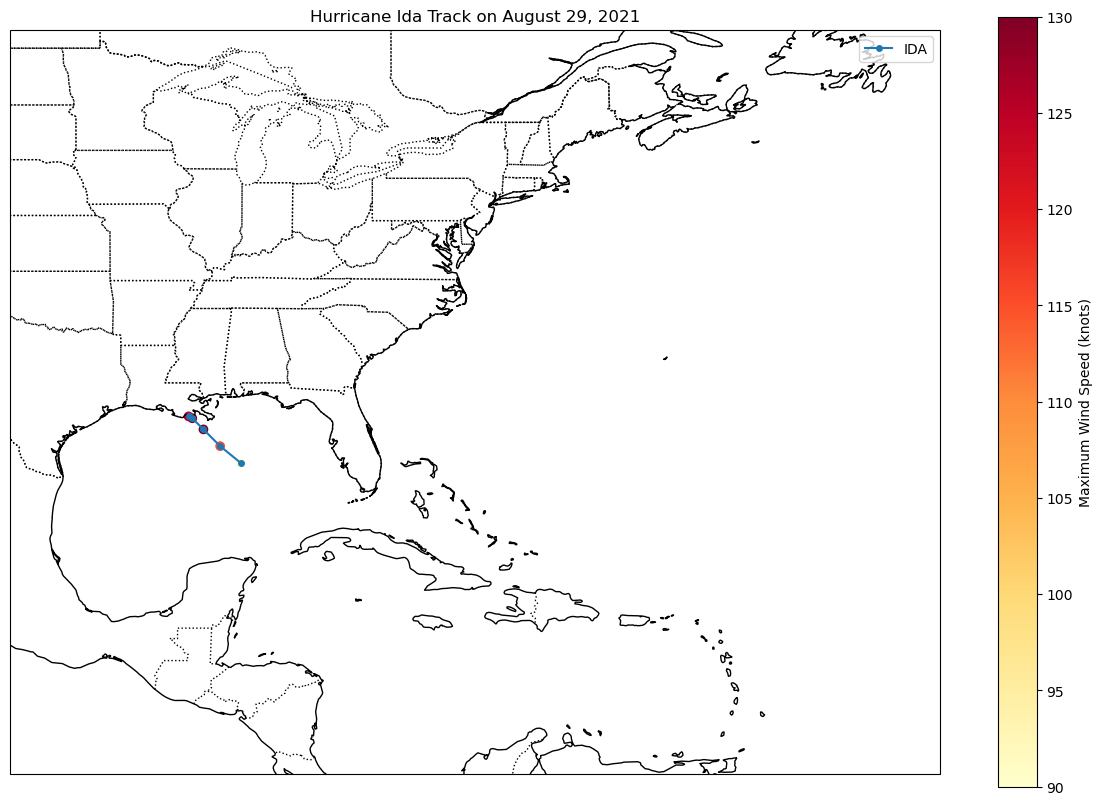

In [19]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Plot hurricane tracks
def plot_hurricane_tracks(hurricane_data, title='Hurricane Tracks'):
    fig = plt.figure(figsize=(15, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.STATES, linestyle=':')
    ax.set_extent([-100, -50, 10, 50], crs=ccrs.PlateCarree())

    # Plot hurricane path
    plt.plot(hurricane_data['longitude'], hurricane_data['latitude'], 
             '-o', markersize=4, label=hurricane_data['storm_name'].iloc[0], transform=ccrs.PlateCarree())

    # Color points by intensity
    scatter = plt.scatter(hurricane_data['longitude'], hurricane_data['latitude'], 
                          c=hurricane_data['max_wind'], cmap='YlOrRd', 
                          transform=ccrs.PlateCarree())

    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Maximum Wind Speed (knots)')

    plt.title(title)
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()

# Plot Hurricane Ida's track
plot_hurricane_tracks(ida_aug29, title='Hurricane Ida Track on August 29, 2021')

In [20]:
import numpy as np

# Holland wind profile model
def holland_wind_profile(r, vmax, rmax, B=1.5):
    """
    Calculate wind speed at radius r using Holland model
    r: radius from hurricane center (km)
    vmax: maximum wind speed (knots)
    rmax: radius of maximum wind (km)
    B: shape parameter
    Returns wind speed in knots
    """
    return vmax * (rmax/r)**B * np.exp(1 - (rmax/r)**B)

# Example: Calculate hurricane wind speed at your wind farm location
# Define your wind farm location (in lat, lon)
wind_farm_lat = 38.27  # Your wind farm latitude
wind_farm_lon = -74.68  # Your wind farm longitude

# Function to calculate distance between two lat/lon points (Haversine formula)
def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate the distance between two lat/lon points in km"""
    from math import radians, sin, cos, sqrt, atan2
    
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    distance = 6371 * c  # Earth radius in km
    
    return distance

# Check the contents of ida_aug29
print("Contents of ida_aug29:")
print(ida_aug29)

# Calculate distances to the wind farm
distances = ida_aug29.apply(lambda row: haversine_distance(wind_farm_lat, wind_farm_lon, row['latitude'], row['longitude']), axis=1)
print("\nCalculated distances:")
print(distances)

# Find the closest record
if not distances.empty:
    closest_index = distances.idxmin()
    print(f"\nClosest index: {closest_index}")
    
    if closest_index in ida_aug29.index:
        closest_record = ida_aug29.loc[closest_index]

        # Parameters
        vmax = closest_record['max_wind']  # knots
        distance_km = distances[closest_index]
        rmax = 50  # typical value, can be adjusted

        # Calculate wind speed at wind farm
        wind_speed = holland_wind_profile(distance_km, vmax, rmax)

        print(f"\nDuring Hurricane Ida on August 29, 2021:")
        print(f"Distance from wind farm: {distance_km:.1f} km")
        print(f"Maximum wind speed in hurricane: {vmax} knots")
        print(f"Estimated wind speed at wind farm: {wind_speed:.1f} knots")

        # Check if wind speed exceeds turbine cut-out speed (typically 25 m/s or ~48.6 knots)
        if wind_speed > 48.6:
            print("WARNING: Wind speed exceeds typical turbine cut-out speed!")
    else:
        print("Closest index is not in ida_aug29 index.")
else:
    print("No records found for August 29, 2021.")

Contents of ida_aug29:
      basin cyclone_number   full_id storm_name  year  month  day  hour  \
53139    AL             09  AL092021        IDA  2021      8   29     0   
53140    AL             09  AL092021        IDA  2021      8   29     6   
53141    AL             09  AL092021        IDA  2021      8   29    12   
53142    AL             09  AL092021        IDA  2021      8   29    16   
53143    AL             09  AL092021        IDA  2021      8   29    18   

       minute record_id status  latitude  longitude  max_wind  min_pressure  \
53139       0               HU      26.7      -87.6        90         967.0   
53140       0               HU      27.6      -88.7       115         950.0   
53141       0               HU      28.5      -89.6       130         929.0   
53142      55         L     HU      29.1      -90.2       130         931.0   
53143       0               HU      29.2      -90.4       125         932.0   

       ne_34kt_radius  se_34kt_radius  sw_34kt_radi

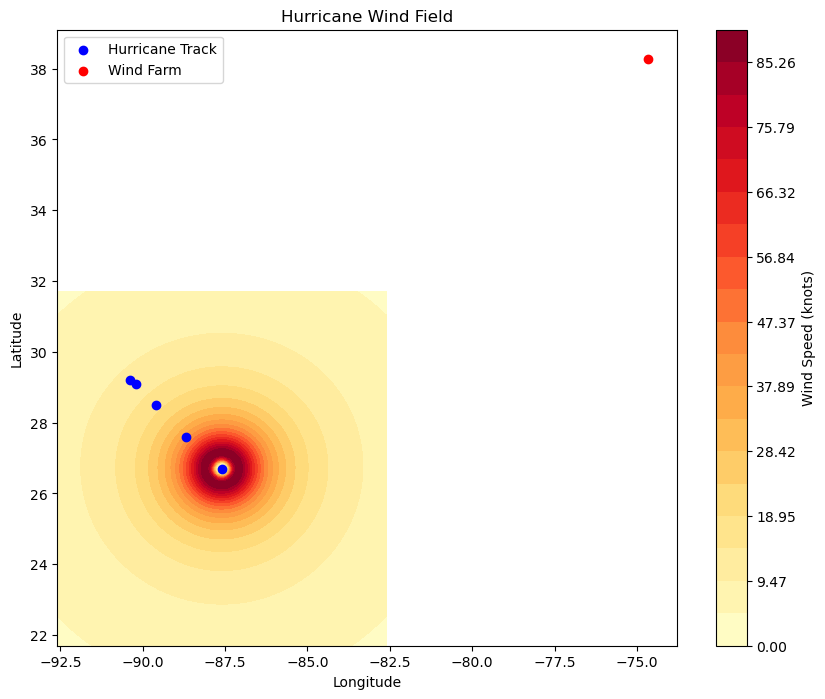

In [21]:
import matplotlib.pyplot as plt

def plot_wind_field(hurricane_data, wind_farm_lat, wind_farm_lon, rmax=50, B=1.5):
    # Define a grid around the hurricane's center
    lat_center = hurricane_data['latitude'].iloc[0]
    lon_center = hurricane_data['longitude'].iloc[0]
    
    lat_range = np.linspace(lat_center - 5, lat_center + 5, 100)
    lon_range = np.linspace(lon_center - 5, lon_center + 5, 100)
    
    lat_grid, lon_grid = np.meshgrid(lat_range, lon_range)
    
    # Calculate wind speeds on the grid
    wind_speeds = np.zeros_like(lat_grid)
    for i in range(lat_grid.shape[0]):
        for j in range(lat_grid.shape[1]):
            distance_km = haversine_distance(lat_center, lon_center, lat_grid[i, j], lon_grid[i, j])
            wind_speeds[i, j] = holland_wind_profile(distance_km, hurricane_data['max_wind'].iloc[0], rmax, B)
    
    # Plot the wind field
    plt.figure(figsize=(10, 8))
    plt.contourf(lon_grid, lat_grid, wind_speeds, levels=np.linspace(0, hurricane_data['max_wind'].iloc[0], 20), cmap='YlOrRd')
    plt.colorbar(label='Wind Speed (knots)')
    plt.scatter(hurricane_data['longitude'], hurricane_data['latitude'], color='blue', label='Hurricane Track')
    plt.scatter(wind_farm_lon, wind_farm_lat, color='red', label='Wind Farm')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Hurricane Wind Field')
    plt.legend()
    plt.show()

# Plot the wind field for Hurricane Ida on August 29, 2021
plot_wind_field(ida_aug29, wind_farm_lat, wind_farm_lon)

In [22]:
# Check if wind speed exceeds turbine cut-out speed (typically 25 m/s or ~48.6 knots)
if wind_speed > 48.6:
    print("WARNING: Wind speed exceeds typical turbine cut-out speed!")
    # Estimate potential damage (this can be based on your specific turbine model and damage thresholds)
    # For example, you can use a damage model to estimate the probability of failure or damage
else:
    print("Wind speed is within safe operating limits.")

Wind speed is within safe operating limits.


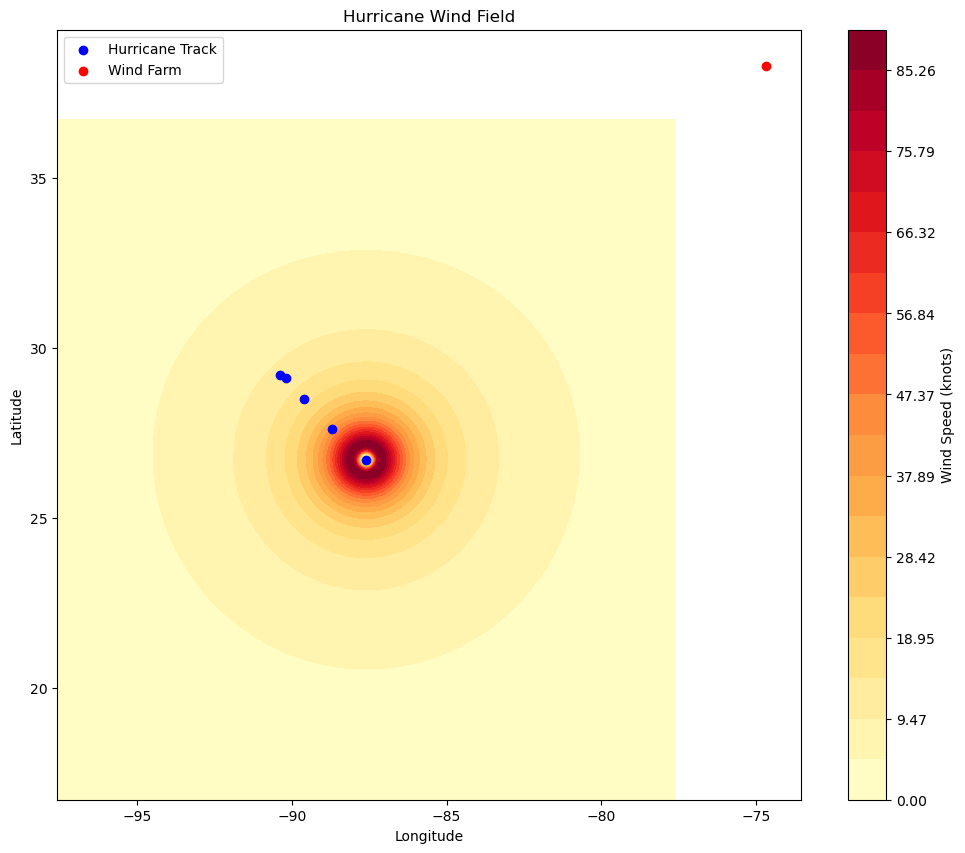

In [23]:
import matplotlib.pyplot as plt
import numpy as np

def plot_wind_field(hurricane_data, wind_farm_lat, wind_farm_lon, rmax=50, B=1.5):
    # Define a grid around the hurricane's center
    lat_center = hurricane_data['latitude'].iloc[0]
    lon_center = hurricane_data['longitude'].iloc[0]
    
    lat_range = np.linspace(lat_center - 10, lat_center + 10, 200)  # Adjusted grid size
    lon_range = np.linspace(lon_center - 10, lon_center + 10, 200)  # Adjusted grid size
    
    lat_grid, lon_grid = np.meshgrid(lat_range, lon_range)
    
    # Calculate wind speeds on the grid
    wind_speeds = np.zeros_like(lat_grid)
    for i in range(lat_grid.shape[0]):
        for j in range(lat_grid.shape[1]):
            distance_km = haversine_distance(lat_center, lon_center, lat_grid[i, j], lon_grid[i, j])
            wind_speeds[i, j] = holland_wind_profile(distance_km, hurricane_data['max_wind'].iloc[0], rmax, B)
    
    # Plot the wind field
    plt.figure(figsize=(12, 10))
    plt.contourf(lon_grid, lat_grid, wind_speeds, levels=np.linspace(0, hurricane_data['max_wind'].iloc[0], 20), cmap='YlOrRd')
    plt.colorbar(label='Wind Speed (knots)')
    plt.scatter(hurricane_data['longitude'], hurricane_data['latitude'], color='blue', label='Hurricane Track')
    plt.scatter(wind_farm_lon, wind_farm_lat, color='red', label='Wind Farm')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Hurricane Wind Field')
    plt.legend()
    plt.show()

# Plot the wind field for Hurricane Ida on August 29, 2021
plot_wind_field(ida_aug29, wind_farm_lat, wind_farm_lon)


Records from August 27, 2011: 4
      basin cyclone_number   full_id storm_name  year  month  day  hour  \
47699    AL             09  AL092011      IRENE  2011      8   27     0   
47700    AL             09  AL092011      IRENE  2011      8   27     6   
47701    AL             09  AL092011      IRENE  2011      8   27    12   
47702    AL             09  AL092011      IRENE  2011      8   27    18   

       minute record_id status  latitude  longitude  max_wind  min_pressure  \
47699       0               HU      32.1      -77.1        75         952.0   
47700       0               HU      33.4      -76.8        75         952.0   
47701       0         L     HU      34.7      -76.6        75         952.0   
47702       0               HU      35.5      -76.3        65         950.0   

       ne_34kt_radius  se_34kt_radius  sw_34kt_radius  nw_34kt_radius  \
47699           225.0           225.0           140.0           140.0   
47700           225.0           225.0           1

/opt/anaconda3/envs/wind/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/wind/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


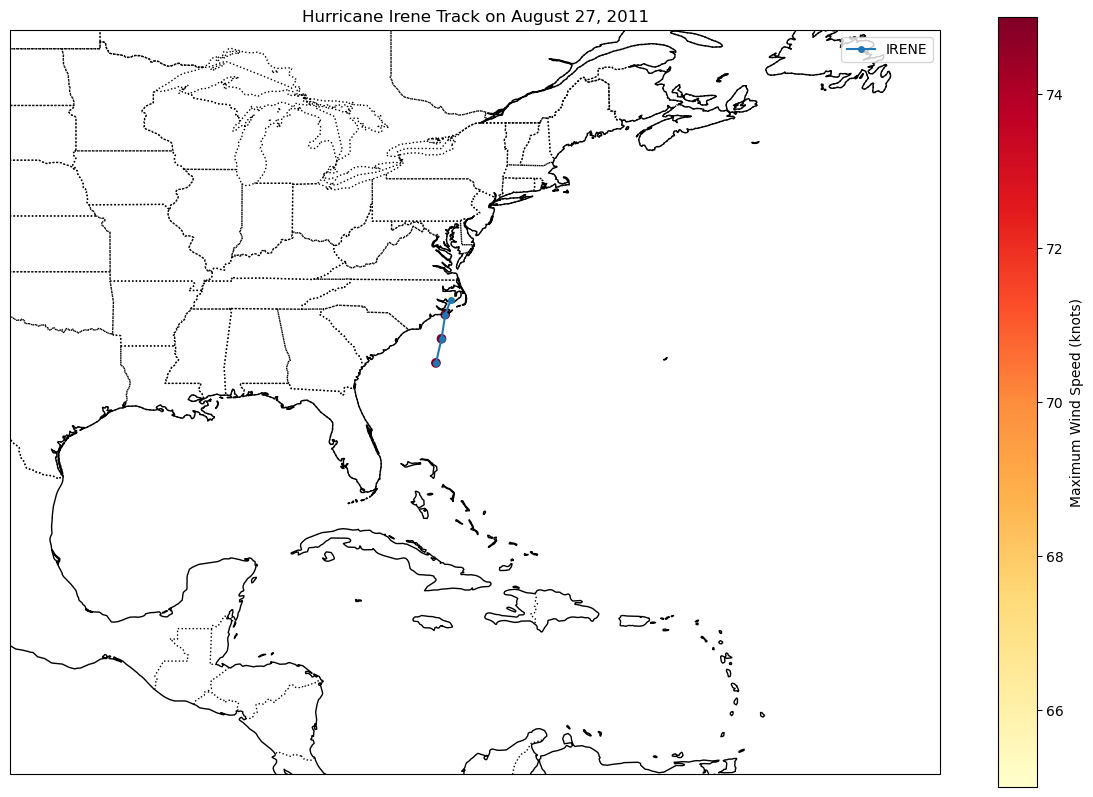

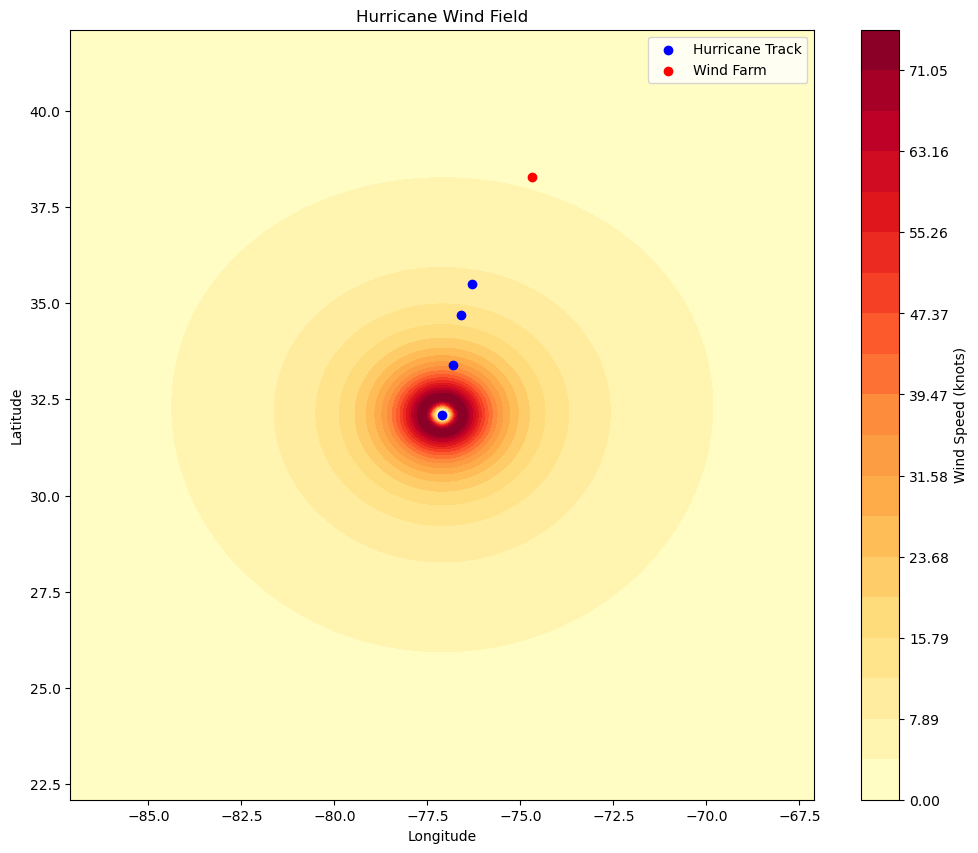

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime

# Function to parse the HURDAT2 file with separated basin and cyclone number
def parse_hurdat2(file_content):
    lines = file_content.strip().split('\n')
    data = []
    current_header = None
    
    for line in lines:
        if re.match(r'^[A-Z]{2}\d{6}', line):
            parts = line.split(',')
            basin_id = parts[0].strip()
            basin = basin_id[:2]
            cyclone_number = basin_id[2:4]
            year = basin_id[4:8]
            name = parts[1].strip()
            num_entries = int(parts[2].strip())
            current_header = {
                'basin': basin,
                'cyclone_number': cyclone_number,
                'year': year,
                'full_id': basin_id,
                'name': name,
                'num_entries': num_entries
            }
        else:
            if current_header:
                parts = line.split(',')
                date_str = parts[0].strip()
                time_str = parts[1].strip()
                year = int(date_str[0:4])
                month = int(date_str[4:6])
                day = int(date_str[6:8])
                hour = int(time_str[0:2]) if time_str else 0
                minute = int(time_str[2:4]) if len(time_str) >= 4 else 0
                record_id = parts[2].strip()
                status = parts[3].strip()
                lat_str = parts[4].strip()
                lon_str = parts[5].strip()
                lat = float(lat_str[:-1]) * (1 if lat_str[-1] == 'N' else -1)
                lon = float(lon_str[:-1]) * (-1 if lon_str[-1] == 'W' else 1)
                max_wind = int(parts[6].strip()) if parts[6].strip() not in ['-999', ''] else None
                min_pressure = int(parts[7].strip()) if parts[7].strip() not in ['-999', ''] else None
                ne_34kt = int(parts[8].strip()) if len(parts) > 8 and parts[8].strip() not in ['-999', ''] else None
                se_34kt = int(parts[9].strip()) if len(parts) > 9 and parts[9].strip() not in ['-999', ''] else None
                sw_34kt = int(parts[10].strip()) if len(parts) > 10 and parts[10].strip() not in ['-999', ''] else None
                nw_34kt = int(parts[11].strip()) if len(parts) > 11 and parts[11].strip() not in ['-999', ''] else None
                ne_50kt = int(parts[12].strip()) if len(parts) > 12 and parts[12].strip() not in ['-999', ''] else None
                se_50kt = int(parts[13].strip()) if len(parts) > 13 and parts[13].strip() not in ['-999', ''] else None
                sw_50kt = int(parts[14].strip()) if len(parts) > 14 and parts[14].strip() not in ['-999', ''] else None
                nw_50kt = int(parts[15].strip()) if len(parts) > 15 and parts[15].strip() not in ['-999', ''] else None
                ne_64kt = int(parts[16].strip()) if len(parts) > 16 and parts[16].strip() not in ['-999', ''] else None
                se_64kt = int(parts[17].strip()) if len(parts) > 17 and parts[17].strip() not in ['-999', ''] else None
                sw_64kt = int(parts[18].strip()) if len(parts) > 18 and parts[18].strip() not in ['-999', ''] else None
                nw_64kt = int(parts[19].strip()) if len(parts) > 19 and parts[19].strip() not in ['-999', ''] else None
                rmw = int(parts[20].strip()) if len(parts) > 20 and parts[20].strip() not in ['-999', ''] else None
                data.append({
                    'basin': current_header['basin'],
                    'cyclone_number': current_header['cyclone_number'],
                    'full_id': current_header['full_id'],
                    'storm_name': current_header['name'],
                    'year': year,
                    'month': month,
                    'day': day,
                    'hour': hour,
                    'minute': minute,
                    'record_id': record_id,
                    'status': status,
                    'latitude': lat,
                    'longitude': lon,
                    'max_wind': max_wind,
                    'min_pressure': min_pressure,
                    'ne_34kt_radius': ne_34kt,
                    'se_34kt_radius': se_34kt,
                    'sw_34kt_radius': sw_34kt,
                    'nw_34kt_radius': nw_34kt,
                    'ne_50kt_radius': ne_50kt,
                    'se_50kt_radius': se_50kt,
                    'sw_50kt_radius': sw_50kt,
                    'nw_50kt_radius': nw_50kt,
                    'ne_64kt_radius': ne_64kt,
                    'se_64kt_radius': se_64kt,
                    'sw_64kt_radius': sw_64kt,
                    'nw_64kt_radius': nw_64kt,
                    'radius_max_wind': rmw
                })
    
    df = pd.DataFrame(data)
    df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute']])
    return df

# Parse the HURDAT2 data with the updated function
with open('project_folder/Wind/Hurricane/NOAA HURDAT2/hurdat2-1851-2023-051124.txt', 'r') as f:
    content = f.read()
    
hurdat_df = parse_hurdat2(content)

# Select Hurricane Irene (AL092011)
irene_data = hurdat_df[(hurdat_df['basin'] == 'AL') & 
                       (hurdat_df['cyclone_number'] == '09') & 
                       (hurdat_df['year'] == 2011)]

# Find specific records from August 27, 2011 (example date)
irene_aug27 = irene_data[(irene_data['month'] == 8) & (irene_data['day'] == 27)]
print(f"\nRecords from August 27, 2011: {len(irene_aug27)}")

# Display all records from August 27
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(irene_aug27)

# Define your wind farm location (in lat, lon)
wind_farm_lat = 38.27  # Your wind farm latitude
wind_farm_lon = -74.68  # Your wind farm longitude

# Function to calculate distance between two lat/lon points (Haversine formula)
def haversine_distance(lat1, lon1, lat2, lon2):
    from math import radians, sin, cos, sqrt, atan2
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    distance = 6371 * c  # Earth radius in km
    return distance

# Calculate distances to the wind farm
distances = irene_aug27.apply(lambda row: haversine_distance(wind_farm_lat, wind_farm_lon, row['latitude'], row['longitude']), axis=1)
print("\nCalculated distances:")
print(distances)

# Find the closest record
if not distances.empty:
    closest_index = distances.idxmin()
    closest_record = irene_aug27.loc[closest_index]

    # Parameters
    vmax = closest_record['max_wind']  # knots
    distance_km = distances[closest_index]
    rmax = 50  # typical value, can be adjusted

    # Holland wind profile model
    def holland_wind_profile(r, vmax, rmax, B=1.5):
        return vmax * (rmax/r)**B * np.exp(1 - (rmax/r)**B)

    # Calculate wind speed at wind farm
    wind_speed = holland_wind_profile(distance_km, vmax, rmax)

    print(f"\nDuring Hurricane Irene on August 27, 2011:")
    print(f"Distance from wind farm: {distance_km:.1f} km")
    print(f"Maximum wind speed in hurricane: {vmax} knots")
    print(f"Estimated wind speed at wind farm: {wind_speed:.1f} knots")

    # Check if wind speed exceeds turbine cut-out speed (typically 25 m/s or ~48.6 knots)
    if wind_speed > 48.6:
        print("WARNING: Wind speed exceeds typical turbine cut-out speed!")
else:
    print("No records found for August 27, 2011.")

# Plot hurricane tracks
def plot_hurricane_tracks(hurricane_data, title='Hurricane Tracks'):
    fig = plt.figure(figsize=(15, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.STATES, linestyle=':')
    ax.set_extent([-100, -50, 10, 50], crs=ccrs.PlateCarree())

    # Plot hurricane path
    plt.plot(hurricane_data['longitude'], hurricane_data['latitude'], 
             '-o', markersize=4, label=hurricane_data['storm_name'].iloc[0], transform=ccrs.PlateCarree())

    # Color points by intensity
    scatter = plt.scatter(hurricane_data['longitude'], hurricane_data['latitude'], 
                          c=hurricane_data['max_wind'], cmap='YlOrRd', 
                          transform=ccrs.PlateCarree())

    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Maximum Wind Speed (knots)')

    plt.title(title)
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()

# Plot the wind field for Hurricane Irene on August 27, 2011
plot_hurricane_tracks(irene_aug27, title='Hurricane Irene Track on August 27, 2011')

# Plot wind field
def plot_wind_field(hurricane_data, wind_farm_lat, wind_farm_lon, rmax=50, B=1.5):
    lat_center = hurricane_data['latitude'].iloc[0]
    lon_center = hurricane_data['longitude'].iloc[0]
    
    lat_range = np.linspace(lat_center - 10, lat_center + 10, 200)
    lon_range = np.linspace(lon_center - 10, lon_center + 10, 200)
    
    lat_grid, lon_grid = np.meshgrid(lat_range, lon_range)
    
    wind_speeds = np.zeros_like(lat_grid)
    for i in range(lat_grid.shape[0]):
        for j in range(lat_grid.shape[1]):
            distance_km = haversine_distance(lat_center, lon_center, lat_grid[i, j], lon_grid[i, j])
            wind_speeds[i, j] = holland_wind_profile(distance_km, hurricane_data['max_wind'].iloc[0], rmax, B)
    
    plt.figure(figsize=(12, 10))
    plt.contourf(lon_grid, lat_grid, wind_speeds, levels=np.linspace(0, hurricane_data['max_wind'].iloc[0], 20), cmap='YlOrRd')
    plt.colorbar(label='Wind Speed (knots)')
    plt.scatter(hurricane_data['longitude'], hurricane_data['latitude'], color='blue', label='Hurricane Track')
    plt.scatter(wind_farm_lon, wind_farm_lat, color='red', label='Wind Farm')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Hurricane Wind Field')
    plt.legend()
    plt.show()

# Plot the wind field for Hurricane Irene on August 27, 2011
plot_wind_field(irene_aug27, wind_farm_lat, wind_farm_lon)

In [25]:
# Extract wind speed and direction at the wind farm location
wind_speed_at_farm = wind_speed
wind_direction_at_farm = None  # Add code to extract wind direction if available

# Extract central pressure
central_pressure = ida_data['min_pressure'].min()

# Extract storm track
storm_track = ida_data[['datetime', 'latitude', 'longitude', 'max_wind']]

# Extract radius of wind
wind_radii = ida_data[['ne_34kt_radius', 'se_34kt_radius', 'sw_34kt_radius', 'nw_34kt_radius',
                       'ne_50kt_radius', 'se_50kt_radius', 'sw_50kt_radius', 'nw_50kt_radius',
                       'ne_64kt_radius', 'se_64kt_radius', 'sw_64kt_radius', 'nw_64kt_radius',
                       'radius_max_wind']]

# Extract landfall events
landfall_events = ida_data[ida_data['record_id'] == 'L'][['datetime', 'latitude', 'longitude', 'max_wind', 'min_pressure']]

# Determine storm intensity category
max_wind_speed = ida_data['max_wind'].max()
if max_wind_speed >= 137:
    intensity_category = 'Category 5'
elif max_wind_speed >= 113:
    intensity_category = 'Category 4'
elif max_wind_speed >= 96:
    intensity_category = 'Category 3'
elif max_wind_speed >= 83:
    intensity_category = 'Category 2'
elif max_wind_speed >= 64:
    intensity_category = 'Category 1'
else:
    intensity_category = 'Tropical Storm'

# Calculate duration of hurricane impact
duration = (ida_data['datetime'].max() - ida_data['datetime'].min()).total_seconds() / 3600  # in hours

# Define turbine cut-out speed
turbine_cut_out_speed = 48.6  # knots

# Simulate turbine damage
turbine_damage = wind_speed_at_farm > turbine_cut_out_speed

# Estimate energy production impact
energy_production_impact = {
    'Downtime': duration if turbine_damage else 0,
    'ReducedOutput': wind_speed_at_farm if turbine_damage else 0
}

# Print extracted outputs
print(f"Wind speed at wind farm: {wind_speed_at_farm:.2f} knots")
print(f"Central pressure: {central_pressure:.2f} mb")
print(f"Storm track:\n{storm_track}")
print(f"Wind radii:\n{wind_radii}")
print(f"Landfall events:\n{landfall_events}")
print(f"Storm intensity category: {intensity_category}")
print(f"Duration of hurricane impact: {duration:.2f} hours")
print(f"Turbine cut-out speed: {turbine_cut_out_speed} knots")
print(f"Turbine damage: {turbine_damage}")
print(f"Energy production impact: {energy_production_impact}")

Wind speed at wind farm: 9.42 knots
Central pressure: 929.00 mb
Storm track:
                 datetime  latitude  longitude  max_wind
53128 2021-08-26 12:00:00      16.5      -78.9        30
53129 2021-08-26 18:00:00      17.4      -79.5        35
53130 2021-08-27 00:00:00      18.3      -80.2        40
53131 2021-08-27 06:00:00      19.4      -80.9        45
53132 2021-08-27 12:00:00      20.4      -81.7        55
53133 2021-08-27 18:00:00      21.5      -82.6        70
53134 2021-08-27 23:25:00      22.4      -83.2        70
53135 2021-08-28 00:00:00      22.6      -83.5        70
53136 2021-08-28 06:00:00      23.5      -84.7        70
53137 2021-08-28 12:00:00      24.4      -85.7        70
53138 2021-08-28 18:00:00      25.6      -86.6        80
53139 2021-08-29 00:00:00      26.7      -87.6        90
53140 2021-08-29 06:00:00      27.6      -88.7       115
53141 2021-08-29 12:00:00      28.5      -89.6       130
53142 2021-08-29 16:55:00      29.1      -90.2       130
53143 2021-